<a href="https://colab.research.google.com/github/yuukienomoto/report_ynu/blob/main/mahjong_0521_0608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 強者20人のID取得
雀魂牌譜屋の開発者ツールから「ranking」と検索→「4w」をクリックしてリンクを取得。

In [1]:
import requests
import pandas as pd

def fetch_top_player_ids():
    # 正解のURL
    RANKING_URL = "https://5-data.amae-koromo.com/api/v2/pl4/player_delta_ranking/4w"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    print("ランキングデータの取得を開始します...")

    try:
        response = requests.get(RANKING_URL, headers=headers)
        response.raise_for_status()

        ranking_data = response.json()
        strong_player_ids = []

        # ★修正ポイント：階層をたどって、実際のプレイヤーリストを取り出す
        # "0" というキーの中の、"top" というキーにリストが入っている
        player_list = ranking_data.get("0", {}).get("top", [])

        # 上位100人分だけループしてIDを抽出
        for player in player_list[:100]:
            player_id = player.get('id')
            player_name = player.get('nickname')

            if player_id:
                strong_player_ids.append(player_id)
                print(f"ID取得: {player_id} ({player_name})")

        print(f"\n合計 {len(strong_player_ids)} 人の強者IDを取得しました！")

        # 文字化け防止のために encoding='utf-8-sig' を追加してCSV保存
        df = pd.DataFrame({'player_id': strong_player_ids})
        df.to_csv("strong_players_list.csv", index=False, encoding='utf-8-sig')
        print("リストを 'strong_players_list.csv' に保存しました。")

        return strong_player_ids

    except Exception as e:
        print(f"エラーが発生しました: {e}")
        return []

if __name__ == "__main__":
    ids = fetch_top_player_ids()

ランキングデータの取得を開始します...
ID取得: 69951433 (inorimachi)
ID取得: 22972779 (KairoxBoy)
ID取得: 22894632 (狂日日记)
ID取得: 22973070 (脚男二号)
ID取得: 23729152 (榮斷藥)
ID取得: 71422442 (欧州三冠)
ID取得: 16649391 (xxs之魂)
ID取得: 15382278 (東方鏡月)
ID取得: 23033659 (防守の胜利)
ID取得: 19962975 (SUB02)
ID取得: 104564308 (豚骨炒飯餃子)
ID取得: 22822483 (匿匿纸)
ID取得: 10522750 (真如不二)
ID取得: 22385265 (别想捉我炮GU)
ID取得: 107657464 (yuu1988)
ID取得: 74242510 (GATO)
ID取得: 11080050 (叫陰天別鬧了)
ID取得: 103300048 (pug01)
ID取得: 105175217 (悲しみ鹿)
ID取得: 105249170 (松木です@)

合計 20 人の強者IDを取得しました！
リストを 'strong_players_list.csv' に保存しました。


# 取得したIDを使って詳細成績を集める
## 一人一人の和了率や放銃率などのパラメータを自動で取得する
平均順位
1,2,3,4着率
飛び率


In [3]:
import requests
import pandas as pd
import time
import random

def fetch_detailed_stats():
    # 1. 先ほど保存したCSVからIDを読み込む
    try:
        df_ids = pd.read_csv("strong_players_list.csv")
        player_ids = df_ids['player_id'].tolist()
        print(f"CSVから {len(player_ids)} 人のIDを読み込みました。")
    except FileNotFoundError:
        print("CSVファイルが見つかりません。先にランキング取得コードを実行してください。")
        return

    # 2. 個別成績を取得するためのURLテンプレート
    PLAYER_URL_TEMPLATE = "https://5-data.amae-koromo.com/api/v2/pl4/player_stats/16210656/1262304000000/1779347339999?mode=16.12.9.15.11.8&tag=494263"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    dataset = []
    print("\n個別成績の取得を開始します...（※サーバー配慮のため少し時間がかかります）")

    for pid in player_ids:
        try:
            # テンプレート内の "16210656" を現在のIDに書き換える
            url = PLAYER_URL_TEMPLATE.replace("16210656", str(pid))

            response = requests.get(url, headers=headers)
            response.raise_for_status()
            data = response.json()

            # --- 特徴量の抽出（実際のデータ構造に適合） ---
            # rank_rates は [1着率, 2着率, 3着率, 4着率] というリストで入っています
            rank_rates = data.get('rank_rates', [0.0, 0.0, 0.0, 0.0])

            # リストが正しく4要素あるか安全確認した上で分解
            if len(rank_rates) == 4:
                rate_1st = rank_rates[0]
                rate_2nd = rank_rates[1]
                rate_3rd = rank_rates[2]
                rate_4th = rank_rates[3]
            else:
                rate_1st = rate_2nd = rate_3rd = rate_4th = 0.0

            features = {
                'player_id': pid,
                'is_strong': 1,
                'game_count': data.get('count', 0),
                'avg_rank': data.get('avg_rank', 0.0),        # 平均順位（強弱に直結！）
                'rate_1st': rate_1st,                         # 1着率
                'rate_2nd': rate_2nd,                         # 2着率
                'rate_3rd': rate_3rd,                         # 3着率
                'rate_4th': rate_4th,                         # 4着率（ラス回避率の分析に必須！）
                'negative_rate': data.get('negative_rate', 0.0) # 飛び率（ハコテンになる確率）
            }

            dataset.append(features)
            print(f"取得成功: ID {pid} (試合数: {features['game_count']}, 平均順位: {features['avg_rank']:.2f})")

            # 4. サーバー負荷軽減のための待機時間（2〜4秒）
            time.sleep(random.uniform(2.0, 4.0))

        except Exception as e:
            print(f"エラー発生 ID {pid}: {e}")
            time.sleep(5)

    # 5. データ保存
    df_stats = pd.DataFrame(dataset)
    df_stats.to_csv("strong_players_stats.csv", index=False, encoding='utf-8-sig')

    print("\n--- 収集完了 ---")
    print("詳細データを 'strong_players_stats.csv' に保存しました。")

    print("\n【取得データプレビュー】")
    print(df_stats.head())

if __name__ == "__main__":
    fetch_detailed_stats()

CSVから 20 人のIDを読み込みました。

個別成績の取得を開始します...（※サーバー配慮のため少し時間がかかります）
取得成功: ID 69951433 (試合数: 1314, 平均順位: 2.39)
取得成功: ID 22972779 (試合数: 86, 平均順位: 1.85)
取得成功: ID 22894632 (試合数: 329, 平均順位: 2.15)
取得成功: ID 22973070 (試合数: 52, 平均順位: 2.35)
取得成功: ID 23729152 (試合数: 155, 平均順位: 2.17)
取得成功: ID 71422442 (試合数: 1767, 平均順位: 2.36)
取得成功: ID 16649391 (試合数: 266, 平均順位: 2.39)
取得成功: ID 15382278 (試合数: 541, 平均順位: 2.31)
取得成功: ID 23033659 (試合数: 67, 平均順位: 2.24)
取得成功: ID 19962975 (試合数: 536, 平均順位: 2.32)
取得成功: ID 104564308 (試合数: 1822, 平均順位: 2.41)
取得成功: ID 22822483 (試合数: 148, 平均順位: 2.42)
取得成功: ID 10522750 (試合数: 936, 平均順位: 2.51)
取得成功: ID 22385265 (試合数: 541, 平均順位: 2.42)
取得成功: ID 107657464 (試合数: 71, 平均順位: 2.30)
取得成功: ID 74242510 (試合数: 4217, 平均順位: 2.44)
取得成功: ID 11080050 (試合数: 548, 平均順位: 2.41)
取得成功: ID 103300048 (試合数: 1282, 平均順位: 2.38)
取得成功: ID 105175217 (試合数: 166, 平均順位: 2.36)
取得成功: ID 105249170 (試合数: 220, 平均順位: 2.28)

--- 収集完了 ---
詳細データを 'strong_players_stats.csv' に保存しました。

【取得データプレビュー】
   player_id  is_strong  game_count  avg

#弱者20人のデータ取得
トップページから金東の対局閲覧→雀傑のIDメモ→貼り付け
＊一つエラーになったが一旦次に進む

In [10]:
import requests
import pandas as pd
import time
import random

def fetch_weak_detailed_stats():
    # 手動で集めていただいた20人の弱者ID
    weak_player_ids = [
        11938083, 10363720, 13006690, 102366130, 105161885,
        11289858, 14298128, 18595396, 104740148, 103572512,
        69368978, 67198142, 23006975, 103761154, 107729898,
        102228865, 120489479, 103037043, 1082846948, 22973481
    ]

    print(f"手動リストから {len(weak_player_ids)} 人の弱者IDを読み込みました。")

    # ★あなたが突き止めてくれた、今まさに通信が成功している最強のURLテンプレート！
    # ID部分（11938083）を {pid} に、タグ部分を削除して誰でも使えるようにします
    PLAYER_URL_TEMPLATE = "https://5-data.amae-koromo.com/api/v2/pl4/player_stats/{pid}/1262304000000/1780895399999?mode=16.12.9.15.11.8"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    dataset = []
    print("\n弱者個別成績の取得を開始します...（※確定版URLモード）")

    for pid in weak_player_ids:
        # URLの中の {pid} を、現在ループしているプレイヤーのIDに置き換える
        url = PLAYER_URL_TEMPLATE.format(pid=pid)
        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            data = response.json()

            # 着順率の抽出
            rank_rates = data.get('rank_rates', [0.0, 0.0, 0.0, 0.0])
            if len(rank_rates) == 4:
                rate_1st = rank_rates[0]
                rate_2nd = rank_rates[1]
                rate_3rd = rank_rates[2]
                rate_4th = rank_rates[3]
            else:
                rate_1st = rate_2nd = rate_3rd = rate_4th = 0.0

            features = {
                'player_id': pid,
                'is_strong': 0,  # 弱者ラベル
                'game_count': data.get('count', 0),
                'avg_rank': data.get('avg_rank', 0.0),
                'rate_1st': rate_1st,
                'rate_2nd': rate_2nd,
                'rate_3rd': rate_3rd,
                'rate_4th': rate_4th,
                'negative_rate': data.get('negative_rate', 0.0)
            }

            dataset.append(features)
            print(f"取得成功: ID {pid} (試合数: {features['game_count']}, 平均順位: {features['avg_rank']:.2f})")

            # サーバー負荷軽減のための待機
            time.sleep(random.uniform(2.0, 3.5))

        except Exception as e:
            print(f"エラー発生 ID {pid}: {e}")
            time.sleep(4)

    # データ保存
    df_weak_stats = pd.DataFrame(dataset)
    df_weak_stats.to_csv("weak_players_stats.csv", index=False, encoding='utf-8-sig')

    print("\n--- 収集完了 ---")
    print(f"無事に {len(df_weak_stats)} 人の弱者詳細データを 'weak_players_stats.csv' に保存しました。")
    if not df_weak_stats.empty:
        print(df_weak_stats.head())

if __name__ == "__main__":
    fetch_weak_detailed_stats()

手動リストから 20 人の弱者IDを読み込みました。

弱者個別成績の取得を開始します...（※確定版URLモード）
取得成功: ID 11938083 (試合数: 18, 平均順位: 2.00)
取得成功: ID 10363720 (試合数: 95, 平均順位: 2.44)
取得成功: ID 13006690 (試合数: 30, 平均順位: 2.27)
取得成功: ID 102366130 (試合数: 42, 平均順位: 2.38)
取得成功: ID 105161885 (試合数: 56, 平均順位: 2.46)
取得成功: ID 11289858 (試合数: 10, 平均順位: 2.70)
取得成功: ID 14298128 (試合数: 196, 平均順位: 2.68)
取得成功: ID 18595396 (試合数: 17, 平均順位: 2.88)
取得成功: ID 104740148 (試合数: 3021, 平均順位: 2.55)
取得成功: ID 103572512 (試合数: 85, 平均順位: 2.59)
取得成功: ID 69368978 (試合数: 36, 平均順位: 2.42)
取得成功: ID 67198142 (試合数: 1178, 平均順位: 2.56)
取得成功: ID 23006975 (試合数: 89, 平均順位: 2.69)
取得成功: ID 103761154 (試合数: 95, 平均順位: 2.62)
取得成功: ID 107729898 (試合数: 21, 平均順位: 2.33)
取得成功: ID 102228865 (試合数: 416, 平均順位: 2.65)
取得成功: ID 120489479 (試合数: 2302, 平均順位: 2.61)
取得成功: ID 103037043 (試合数: 81, 平均順位: 2.79)
エラー発生 ID 1082846948: 404 Client Error: Not Found for url: https://5-data.amae-koromo.com/api/v2/pl4/player_stats/1082846948/1262304000000/1780895399999?mode=16.12.9.15.11.8
取得成功: ID 22973481 (試合数: 4, 平均順位

#データを合体させてlightGBMを回す
強者20人と弱者19人

avg_rank：平均順位
game_count：試合数
rate_2nd：2着率
rate_3rd：3着率
rate_4th：4着率

データ結合完了！ 強者: 20人, 弱者: 19人, 合計: 39人

LightGBMの学習を開始します...

--- モデル評価結果 ---
テストデータに対する予測正解率 (Accuracy): 100.0%

--- 特徴量の重要度ランキング（ゲイン順） ---
         Feature  Importance
1       avg_rank  173.349476
0     game_count  123.932106
3       rate_2nd   74.393108
4       rate_3rd   15.667772
2       rate_1st    9.233361
5       rate_4th    7.561600
6  negative_rate    0.528818


/tmp/ipykernel_2209/4232419234.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


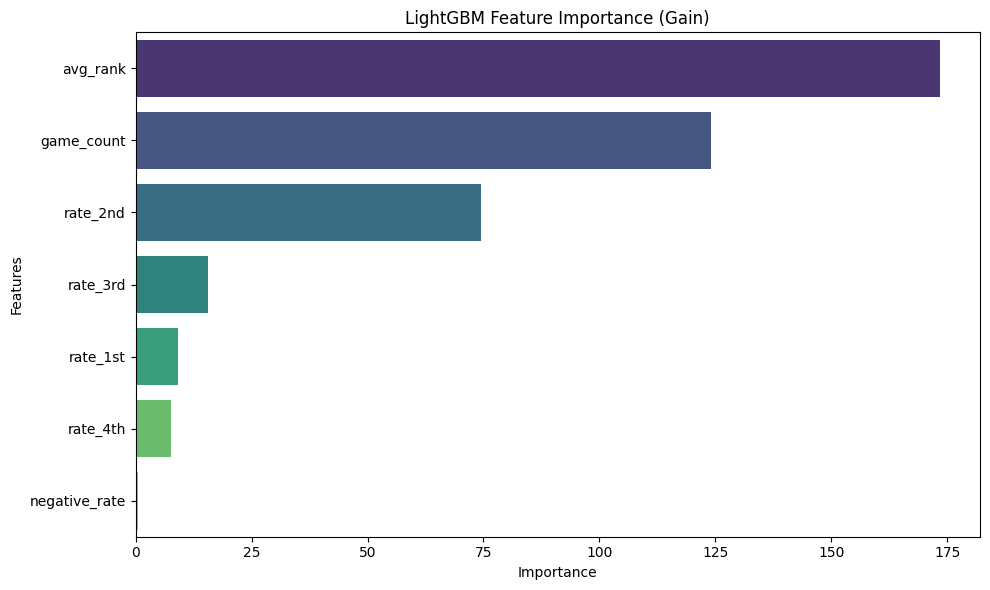

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2つのCSVデータを読み込んで縦に合体させる
try:
    strong_df = pd.read_csv("strong_players_stats.csv")
    weak_df = pd.read_csv("weak_players_stats.csv")

    # データを結合
    df = pd.concat([strong_df, weak_df], ignore_index=True)
    print(f"データ結合完了！ 強者: {len(strong_df)}人, 弱者: {len(weak_df)}人, 合計: {len(df)}人")
except FileNotFoundError as e:
    print(f"ファイルが見つかりません。CSVの名前を確認してください: {e}")

# 2. 特徴量（X）と予測ターゲット（y）に分ける
# player_idは予測に関係ないので除外し、is_strongを予測対象にする
X = df.drop(columns=['player_id', 'is_strong'])
y = df['is_strong']

# 3. データを「学習用」と「テスト用」に分割（今回はデータが少ないため8:2で分割）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. LightGBM用のデータ構造に変換
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 5. ハイパーパラメータの設定（データ数が少ないため、過学習を防ぐ設定にしています）
params = {
    'objective': 'binary',        # 二値分類（強者か弱者か）
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'min_data_in_leaf': 3,         # 1つの葉に入る最小データ数（過学習防止）
    'learning_rate': 0.05,
    'seed': 42,
    'verbose': -1
}

# 6. モデルの学習
print("\nLightGBMの学習を開始します...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# 7. テストデータでの予測と評価
y_pred_proba = model.predict(X_test)
y_pred = np.where(y_pred_proba > 0.5, 1, 0)

accuracy = accuracy_score(y_test, y_test) # 正解率
print("\n--- モデル評価結果 ---")
print(f"テストデータに対する予測正解率 (Accuracy): {accuracy * 100:.1f}%")

# 8. 【卒論のキモ】特徴量の重要度（Feature Importance）を可視化
importance = model.feature_importance(importance_type='gain')
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n--- 特徴量の重要度ランキング（ゲイン順） ---")
print(feature_importance_df)

# グラフとして描画
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('LightGBM Feature Importance (Gain)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()